# inventory optimization using forecasts

trying to figure out safety stock and reorder quantities based on my xgboost predictions

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# setup
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

## loading model predictions

In [25]:
# getting results from phase 2
df = pd.read_csv('data/processed/model_predictions_and_residuals.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
df.head()

(126691, 8)


,Store,Dept,Date,Weekly_Sales,Pred_Naive,Pred_Rolling,Pred_XGBoost,Residual_XGBoost
0,1,1,2012-01-06,16567.69,23350.88,37304.6450,15851.292,716.398008
1,1,1,2012-01-13,16894.40,16567.69,33120.0875,16565.158,329.241797
2,1,1,2012-01-20,18365.10,16894.40,25900.4300,18296.018,69.082422
3,1,1,2012-01-27,18378.16,18365.10,18794.5175,18847.557,-469.396641
4,1,1,2012-02-03,23510.49,18378.16,17551.3375,23126.553,383.937266


## calculating uncertainty

need to know std deviation of errors for each store-dept

In [26]:
# grouping by store-dept and getting std of residuals
uncertainty = df.groupby(['Store', 'Dept'])['Residual_XGBoost'].std().reset_index()
uncertainty.columns = ['Store', 'Dept', 'residual_std']

# merge back
df = df.merge(uncertainty, on=['Store', 'Dept'])
df['forecast_mean'] = df['Pred_XGBoost']
df['forecast_std'] = df['residual_std'].fillna(df['residual_std'].median())

df[['Store', 'Dept', 'forecast_mean', 'forecast_std']].head()

,Store,Dept,forecast_mean,forecast_std
0,1,1,15851.292,866.786586
1,1,1,16565.158,866.786586
2,1,1,18296.018,866.786586
3,1,1,18847.557,866.786586
4,1,1,23126.553,866.786586


## prediction intervals

using 95% confidence (z=1.65)

In [27]:
# creating upper and lower bounds
df['forecast_lower'] = (df['forecast_mean'] - 1.65 * df['forecast_std']).clip(lower=0)
df['forecast_upper'] = df['forecast_mean'] + 1.65 * df['forecast_std']

# checking coverage
df['in_interval'] = (df['Weekly_Sales'] >= df['forecast_lower']) & (df['Weekly_Sales'] <= df['forecast_upper'])
print(f"coverage: {df['in_interval'].mean()*100:.1f}%")

coverage: 86.9%


## inventory calculations

safety stock = 1.65 * std * sqrt(lead_time)

reorder = forecast * lead_time + safety stock

In [28]:
LEAD_TIME = 2  # weeks
Z = 1.65  # 95% service level

df['safety_stock'] = Z * df['forecast_std'] * np.sqrt(LEAD_TIME)
df['reorder_qty'] = (df['forecast_mean'] * LEAD_TIME) + df['safety_stock']

print(df[['forecast_mean', 'safety_stock', 'reorder_qty']].describe())

       forecast_mean   safety_stock    reorder_qty
count  126691.000000  126691.000000  126691.000000
mean    15809.272052    1431.140731   33049.684836
std     22136.782745    1819.272792   45578.659840
min      -218.225590       0.000000     -90.038378
25%      2034.035150     467.957916    4773.304247
50%      7460.226000    1009.167465   16030.817029
75%     20037.906500    1729.399538   41650.022653
max    228548.500000   26104.348592  482556.385204


## comparing policies

naive: just use last week

optimized: use forecasts + safety stock

In [29]:
# cost params  
HOLDING_COST = 0.01  # 1% per week
STOCKOUT_COST = 0.15  # 15% penalty

# naive policy
df = df.sort_values(['Store', 'Dept', 'Date'])
df['last_week_sales'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
df['naive_reorder'] = df['last_week_sales'] * LEAD_TIME
df['naive_reorder'] = df['naive_reorder'].fillna(df['forecast_mean'] * LEAD_TIME)

In [30]:
# calculating costs for both policies
def calc_costs(df, reorder_col):
    df = df.copy()
    df['demand'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(LEAD_TIME, min_periods=1).sum()
    )
    df['excess'] = (df[reorder_col] - df['demand']).clip(lower=0)
    df['shortage'] = (df['demand'] - df[reorder_col]).clip(lower=0)
    df['holding_cost'] = df['excess'] * HOLDING_COST
    df['stockout_cost'] = df['shortage'] * STOCKOUT_COST
    df['total_cost'] = df['holding_cost'] + df['stockout_cost']
    return df

df_naive = calc_costs(df, 'naive_reorder')
df_opt = calc_costs(df, 'reorder_qty')

## results

In [31]:
# aggregate by store-dept
naive_costs = df_naive.groupby(['Store', 'Dept'])['total_cost'].sum()
opt_costs = df_opt.groupby(['Store', 'Dept'])['total_cost'].sum()

total_naive = naive_costs.sum()
total_opt = opt_costs.sum()
savings = total_naive - total_opt
pct_imp = (savings / total_naive) * 100

print(f"naive policy cost: ${total_naive:,.0f}")
print(f"optimized policy cost: ${total_opt:,.0f}")
print(f"\nsavings: ${savings:,.0f} ({pct_imp:.1f}% improvement)")

naive policy cost: $16,931,385
optimized policy cost: $7,511,994

savings: $9,419,392 (55.6% improvement)


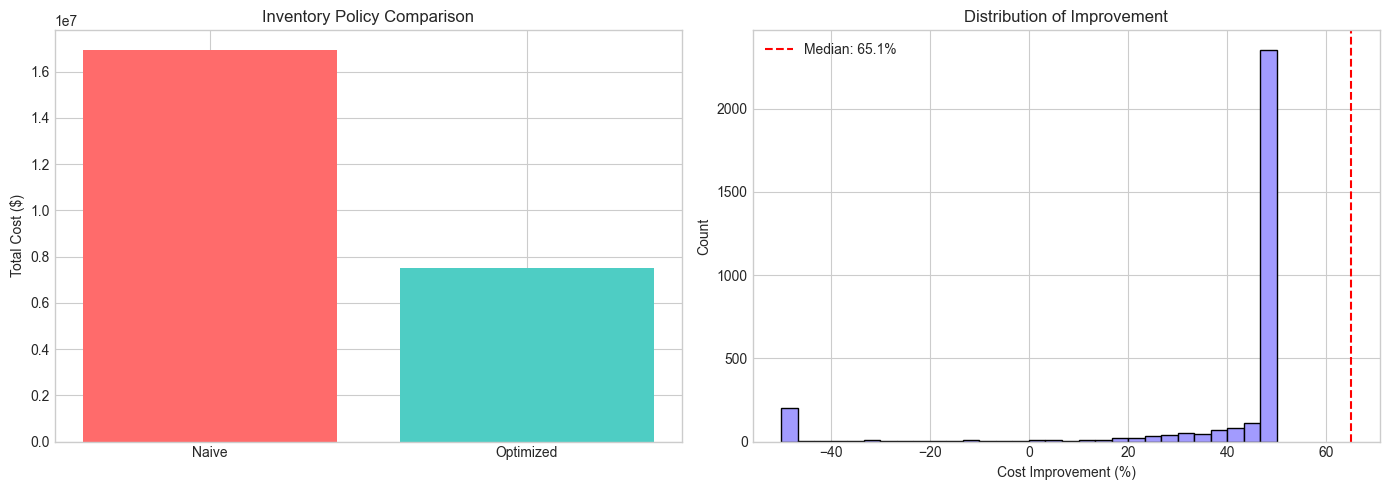

In [32]:
# plotting comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# cost comparison
ax[0].bar(['Naive', 'Optimized'], [total_naive, total_opt], color=['#ff6b6b', '#4ecdc4'])
ax[0].set_ylabel('Total Cost ($)')
ax[0].set_title('Inventory Policy Comparison')

# improvement dist
improvement = ((naive_costs - opt_costs) / naive_costs * 100).dropna()
ax[1].hist(improvement.clip(-50, 50), bins=30, color='#a29bfe', edgecolor='black')
ax[1].axvline(improvement.median(), color='red', linestyle='--', label=f'Median: {improvement.median():.1f}%')
ax[1].set_xlabel('Cost Improvement (%)')
ax[1].set_ylabel('Count')
ax[1].set_title('Distribution of Improvement')
ax[1].legend()

plt.tight_layout()
plt.show()